# Hex Value Learning

Model-free value learning over hexes from maze trajectories.

| Model | What it learns | Update rule |
|---|---|---|
| **HexMazeTDLearner** | V(state) — value of a maze location | **TD(λ)** with eligibility traces (λ=0 → TD(0), λ=1 → Monte Carlo) |

The TD learner is the **model-free** component of a Krausz et al. 2023-style
hex-value model (*Dual credit assignment processes underlie dopamine signals in a
complex spatial environment*, Neuron). The model-based / path-independent
inference component of that paper is **not** implemented here.

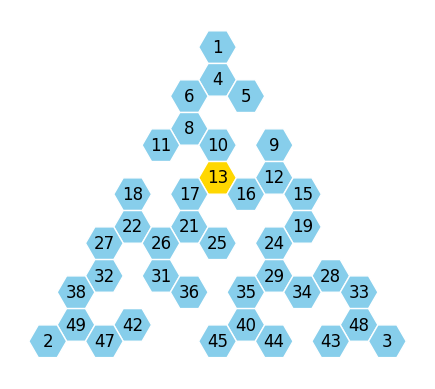

In [1]:
import sys
sys.path.append('..')  # so `src/hexmaze` is importable from Tutorials/

import numpy as np
import matplotlib.pyplot as plt

from src.hexmaze import plot_hex_maze
from src.hexmaze.rl.hex_learning import HexMazeTDLearner

# A maze in any valid format (set/list/string/graph). Here, a set of barrier hexes.
maze = {37, 7, 39, 41, 14, 46, 20, 23, 30}

# Reward probabilities for each port: [Port A, Port B, Port C]
reward_probs = [0.9, 0.5, 0.1]

port_names = {1: 'A', 2: 'B', 3: 'C'}
plot_hex_maze(maze, show_choice_points=True, show_barriers=False)

## Two modes: `simulate` vs `learn`

The TD learner is used in two distinct ways:

- **`simulate(start_state, n_trials)`** — the agent **generates its own behavior**:
  softmax over values → walk to a reward port → sample reward → TD(λ) update →
  start the next trial from where it ended up. Because it is choosing actions from
  the value function, you usually want **`goal_conditioned=True`** so it does not run
  back up the value gradient to the port it just left.

- **`learn(trajectories, rewards, start_ports)`** — you feed in **pre-recorded hex
  paths** (e.g. real rat trajectories). The agent only runs TD(λ) updates; it does no
  action selection, so the U-turn problem never arises. This is the mode that matches
  the paper, which **fits** value to observed behavior rather than generating it.

Both modes share the same flags. The key ones:

| Flag | Effect |
|---|---|
| `lam` | 0 = TD(0) (paper), 1 = Monte Carlo, in between = eligibility-trace blend |
| `directional` | `False`: V over hexes (49). `True`: V over directed edges `(prev, cur)` (~126, the paper's representation) |
| `goal_conditioned` | `True`: 3 tables keyed by start/excluded port (good for `simulate`). `False`: single shared table (the paper's choice) |


## Mode 1 — `simulate`: the agent generates its own behavior

Here the learner picks actions via softmax over its value estimates and learns online.
We use `goal_conditioned=True` (the default) so each trip targets the *other* two ports.

In [2]:
# A TD(lambda) learner set up for self-generated behavior
td = HexMazeTDLearner(
    maze,
    reward_probs=reward_probs,
    alpha=0.3,              # TD learning rate
    lam=0.6,                # eligibility-trace decay: 0=TD(0), 1=Monte Carlo
    gamma=0.95,             # discount factor
    temperature=0.5,        # softmax temperature (lower = more exploitative)
    goal_conditioned=True,  # 3 tables keyed by start port
    directional=False,      # value over plain hexes
    priors=reward_probs,    # init V with gamma^distance * reward_prob
    no_backtrack=True,      # don't revisit hexes within a trial
)

# Generate 200 trials starting from port A (hex 1)
td_results = td.simulate(start_state=1, n_trials=200, max_steps=200)

print(f"Simulated {len(td_results)} trials")
print("\nFirst 5 trials:")
for trial_index, trial in enumerate(td_results[:5]):
    path = trial['path']
    print(f"  Trial {trial_index+1}: start=port {port_names[trial['start_port']]}, "
          f"reward={trial['reward']:.0f}, len={len(path)}, "
          f"path={path[:6]}{'...' if len(path) > 6 else ''}")

rewards = [trial['reward'] for trial in td_results]
print(f"\nOverall reward rate: {np.mean(rewards):.2f}")
print(f"Mean path length: {np.mean([len(trial['path']) for trial in td_results]):.1f} hexes")
for port in [1, 2, 3]:
    port_trials = [trial for trial in td_results if trial['start_port'] == port]
    if port_trials:
        print(f"  From port {port_names[port]}: {len(port_trials)} trials, "
              f"reward rate {np.mean([trial['reward'] for trial in port_trials]):.2f}")

Simulated 200 trials

First 5 trials:
  Trial 1: start=port A, reward=0, len=19, path=[1, 4, 6, 8, 11, 8]...
  Trial 2: start=port C, reward=0, len=27, path=[3, 48, 43, 48, 33, 28]...
  Trial 3: start=port B, reward=1, len=27, path=[2, 49, 38, 32, 27, 22]...
  Trial 4: start=port A, reward=0, len=21, path=[1, 4, 5, 4, 6, 8]...
  Trial 5: start=port C, reward=1, len=25, path=[3, 48, 43, 48, 33, 28]...

Overall reward rate: 0.57
Mean path length: 30.0 hexes
  From port A: 77 trials, reward rate 0.35
  From port B: 65 trials, reward rate 0.62
  From port C: 58 trials, reward rate 0.81


### Visualize learned values

`get_state_values(start_port)` returns `{hex: value}` for one context's table.
(With `directional=True` it collapses incoming directed-edge states to one value per
hex; pass `reduce="mean"` or `"max"`.)

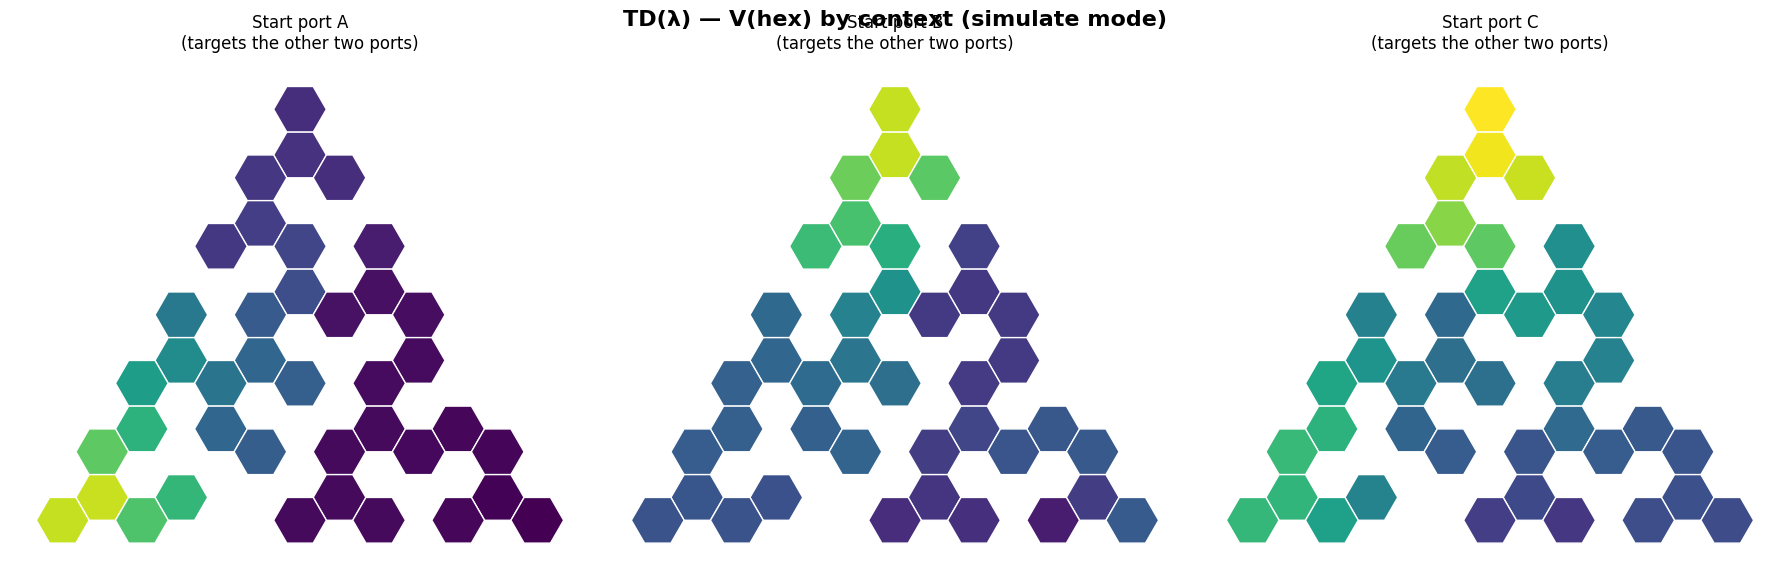

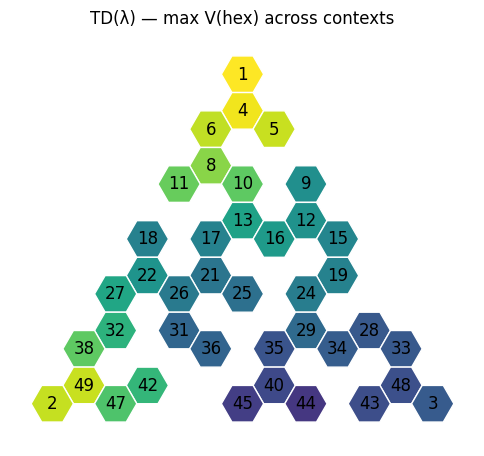

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, port in zip(axes, [1, 2, 3]):
    values = td.get_state_values(start_port=port)
    plot_hex_maze(maze, color_by=values, colormap='viridis',
                  vmin=0, vmax=1, ax=ax, show_hex_labels=False, show_barriers=False)
    ax.set_title(f'Start port {port_names[port]}\n(targets the other two ports)', fontsize=12)
fig.suptitle('TD(λ) — V(hex) by context (simulate mode)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

# Max value across all 3 context tables
max_values = td.get_max_state_values()
fig, ax = plt.subplots(figsize=(6, 6))
plot_hex_maze(maze, color_by=max_values, colormap='viridis',
              vmin=0, vmax=1, show_hex_labels=True, ax=ax, show_barriers=False)
ax.set_title('TD(λ) — max V(hex) across contexts'); plt.show()

## Mode 2 — `learn`: fit value to supplied trajectories

Instead of generating behavior, feed the learner hex paths (e.g. real rat
trajectories). It runs TD(λ) updates only — no action selection. Each trajectory is a
list of hex IDs from start port to reward port, with its reward and start port.

In [4]:
trajectories = [
    [1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 28, 33, 48, 3],    # A -> C
    [3, 48, 33, 28, 34, 29, 24, 19, 15, 12, 16, 13, 10, 8, 6, 4, 1],    # C -> A
    [1, 4, 6, 8, 10, 13, 17, 21, 26, 22, 27, 32, 38, 49, 2],            # A -> B
]
rewards = [1, 0, 1]
start_ports = [1, 3, 1]   # which port each trip started from

td_rat = HexMazeTDLearner(maze, reward_probs, alpha=0.3, lam=0.6, gamma=0.95,
                          goal_conditioned=True)

# learn() runs TD(lambda) on each trajectory in sequence (no behavior generated)
td_rat.learn(trajectories, rewards, start_ports)

print("Learned V(hex) for the port-A context (after 3 trajectories):")
values = td_rat.get_state_values(start_port=1)
for hex, value in sorted(values.items()):
    if abs(value) > 1e-3:
        print(f"  Hex {hex:2d}: V = {value:.4f}")

Learned V(hex) for the port-A context (after 3 trajectories):
  Hex  2: V = 0.3000
  Hex  3: V = 0.3000
  Hex  8: V = 0.0015
  Hex 10: V = 0.0025
  Hex 12: V = 0.0033
  Hex 13: V = 0.0041
  Hex 15: V = 0.0059
  Hex 16: V = 0.0019
  Hex 17: V = 0.0059
  Hex 19: V = 0.0103
  Hex 21: V = 0.0103
  Hex 22: V = 0.0317
  Hex 24: V = 0.0181
  Hex 26: V = 0.0181
  Hex 27: V = 0.0556
  Hex 28: V = 0.0975
  Hex 29: V = 0.0317
  Hex 32: V = 0.0975
  Hex 33: V = 0.1710
  Hex 34: V = 0.0556
  Hex 38: V = 0.1710
  Hex 48: V = 0.3000
  Hex 49: V = 0.3000


## The paper-exact model-free preset

The Krausz 2023 model-free component is **pure TD(0)** over **directional hex-states**
with a **single, non-goal-conditioned** value function and **terminal** reward
ports, initialized to a flat 0.2. It is meant for `learn` (fitting), not `simulate`.

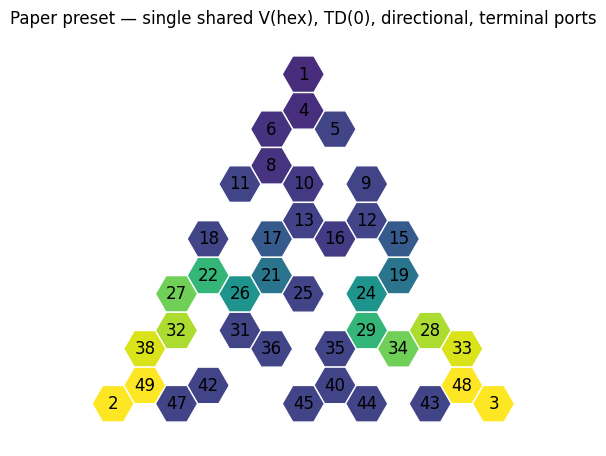

In [5]:
td_paper = HexMazeTDLearner(
    maze, reward_probs,
    lam=0.0,                 # pure TD(0)
    directional=True,        # states are directed edges (prev_hex, cur_hex)
    goal_conditioned=False,  # one shared value function
    priors=('flat', 0.2),    # flat baseline expectation
    alpha=0.3, gamma=0.95,
)

# Replay these routes repeatedly so TD(0) propagates value back along each path,
# one hex per pass (single shared context -> start_port doesn't split tables)
for _ in range(20):
    td_paper.learn(trajectories, rewards, start_ports)

values = td_paper.get_state_values(start_port=1)  # single shared table
fig, ax = plt.subplots(figsize=(6, 6))
plot_hex_maze(maze, color_by=values, colormap='viridis', vmin=0, vmax=1,
              show_hex_labels=True, ax=ax, show_barriers=False)
ax.set_title('Paper preset — single shared V(hex), TD(0), directional, terminal ports')
plt.show()

### Directional states encode approach direction

With `directional=True`, the value of *arriving* at a hex depends on which neighbor you
came from. We can read the raw directed-edge values (`learner.V[context]`, keyed by
`(prev_hex, cur_hex)`) to see this — the same hex has different value depending on the
direction of entry.

In [6]:
context = None  # single shared context (goal_conditioned=False)
for hex in [16, 27, 43]:
    incoming = {prev_hex: value for (prev_hex, cur_hex), value in td_paper.V[context].items() if cur_hex == hex}
    incoming_str = ", ".join(f"from {prev_hex}: {value:.3f}" for prev_hex, value in sorted(incoming.items()))
    print(f"V(arrive at hex {hex:2d})  ->  {incoming_str}")

V(arrive at hex 16)  ->  from 12: 0.068, from 13: 0.172
V(arrive at hex 27)  ->  from 22: 0.784
V(arrive at hex 43)  ->  


## The `lam` knob: TD(0) → Monte Carlo

`lam` controls how far reward propagates **within a single trial**. After learning from
each trajectory just **once**, `lam=0` (TD(0)) has only moved value near the reward port,
while `lam=1` (Monte Carlo) has filled in the entire path. Intermediate `lam` blends the
two via the eligibility trace.

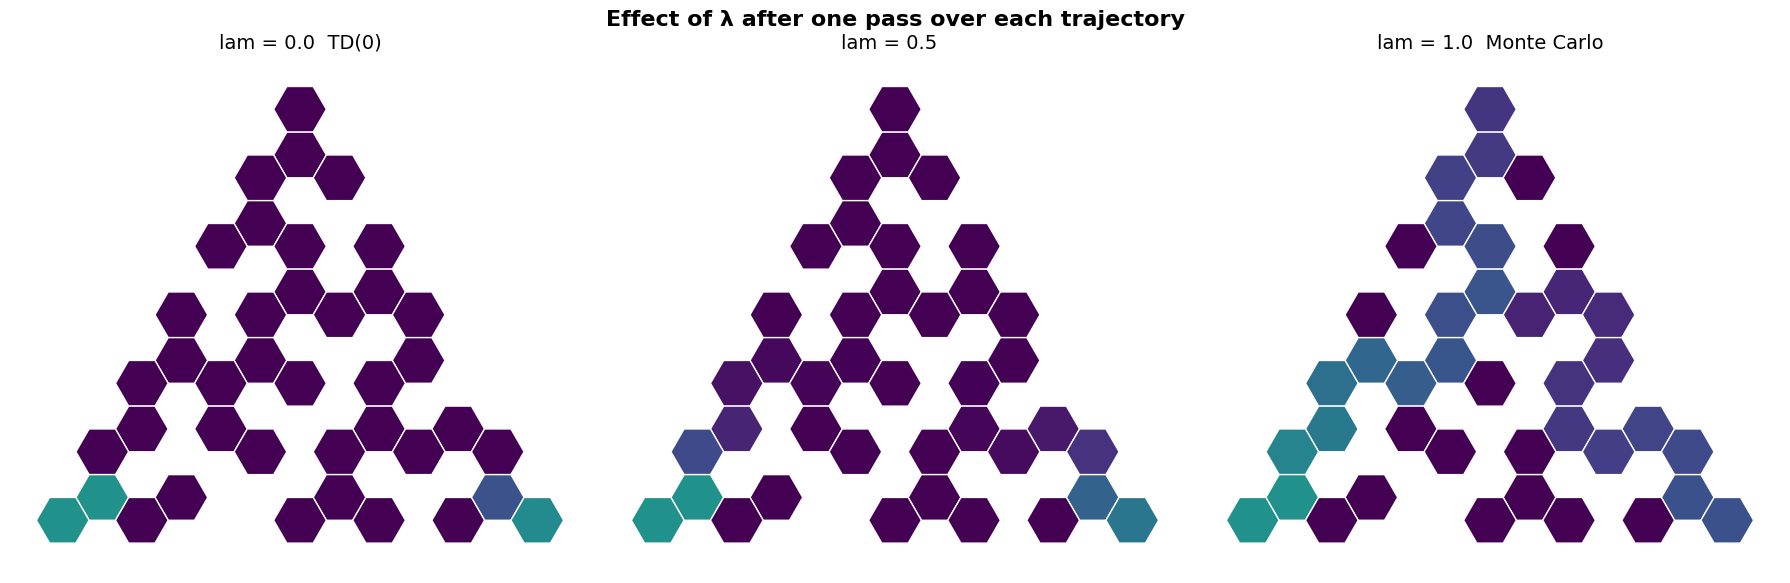

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, lam in zip(axes, [0.0, 0.5, 1.0]):
    td_lam = HexMazeTDLearner(maze, reward_probs, alpha=0.5, lam=lam, gamma=0.9,
                              goal_conditioned=False, directional=False, priors=None)
    # learn each trajectory exactly once -> propagation differences are visible
    td_lam.learn(trajectories, rewards, start_ports)
    plot_hex_maze(maze, color_by=td_lam.get_state_values(start_port=1),
                  colormap='viridis', vmin=0, vmax=1, ax=ax, show_hex_labels=False, show_barriers=False)
    label = {0.0: 'TD(0)', 1.0: 'Monte Carlo'}.get(lam, '')
    ax.set_title(f'lam = {lam}  {label}', fontsize=14)
fig.suptitle('Effect of λ after one pass over each trajectory', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Why `goal_conditioned` matters for `simulate`

In `simulate`, a single shared value function makes the just-departed port (a reward port,
hence high value) attractive — the agent tends to wander back toward it. Goal-conditioning
gives each trip its own table in which the departed port is *not* a target, yielding more
directed paths and a bit more reward. (The effect is larger with `no_backtrack=False`,
which otherwise masks some U-turns.)

In [8]:
def behavior(goal_conditioned, seeds=range(5)):
    reward_rates, path_lengths = [], []
    for seed in seeds:
        np.random.seed(seed)
        td_g = HexMazeTDLearner(maze, reward_probs, alpha=0.3, lam=0.3, gamma=0.95,
                                goal_conditioned=goal_conditioned, directional=False,
                                priors=reward_probs, temperature=0.3, no_backtrack=False)
        results = td_g.simulate(start_state=1, n_trials=200, max_steps=200)
        reward_rates.append(np.mean([trial['reward'] for trial in results]))
        path_lengths.append(np.mean([len(trial['path']) for trial in results]))
    return np.mean(reward_rates), np.mean(path_lengths)

for goal_conditioned in (False, True):
    reward, path_length = behavior(goal_conditioned)
    print(f"goal_conditioned={goal_conditioned!s:5}  reward={reward:.2f}  mean_path_len={path_length:5.1f}  (avg of 5 seeds)")

goal_conditioned=False  reward=0.30  mean_path_len=134.5  (avg of 5 seeds)
goal_conditioned=True   reward=0.47  mean_path_len=116.7  (avg of 5 seeds)


## Step-by-step value history

`process_trajectory_with_history()` returns a snapshot of the (collapsed per-hex) value
tables after each step, so you can watch values update within a single trial. Each entry
is `{"state": hex, "values": {context: {hex: value}}}`.

In [9]:
td_step = HexMazeTDLearner(maze, reward_probs, alpha=0.3, lam=0.6, gamma=0.95,
                           goal_conditioned=True, priors=reward_probs)

trajectory = [1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 28, 33, 48, 3]
history = td_step.process_trajectory_with_history(trajectory, reward=1.0, start_port=1)

print(f"Trajectory: {trajectory}")
print(f"{len(history)} snapshots (initial + one per step)\n")

hexes_to_track = [1, 10, 16, 24, 48, 3]
print(f"{'Step':>4}  {'hex':>5}  " + "  ".join(f"V({hex})" for hex in hexes_to_track))
print("-" * (16 + 8 * len(hexes_to_track)))
for step_index, snap in enumerate(history):
    values = [snap['values'][1].get(hex, 0.0) for hex in hexes_to_track]  # context 1 = port-A table
    print(f"{step_index:>4}  {snap['state']:>5}  " + "  ".join(f"{value:5.3f}" for value in values))

Trajectory: [1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 28, 33, 48, 3]
17 snapshots (initial + one per step)

Step    hex  V(1)  V(10)  V(16)  V(24)  V(48)  V(3)
----------------------------------------------------------------
   0      1  0.270  0.299  0.299  0.299  0.284  0.100
   1      4  0.270  0.299  0.299  0.299  0.284  0.100
   2      6  0.270  0.299  0.299  0.299  0.284  0.100
   3      8  0.270  0.299  0.299  0.299  0.284  0.100
   4     10  0.268  0.299  0.299  0.299  0.284  0.100
   5     13  0.268  0.299  0.299  0.299  0.284  0.100
   6     16  0.268  0.294  0.299  0.299  0.284  0.100
   7     12  0.268  0.291  0.291  0.299  0.284  0.100
   8     15  0.267  0.290  0.286  0.299  0.284  0.100
   9     19  0.267  0.290  0.286  0.299  0.284  0.100
  10     24  0.267  0.290  0.286  0.299  0.284  0.100
  11     29  0.267  0.290  0.286  0.299  0.284  0.100
  12     34  0.267  0.290  0.285  0.294  0.284  0.100
  13     28  0.267  0.289  0.285  0.291  0.284  0.100
  14     33 

## Action probabilities

`action_probabilities(hex, start_port)` gives the softmax policy at a hex — the
probability of moving to each neighbor, based on the value of entering it.

In [10]:
print("TD(λ) learner — action probabilities (port-A context):")
for hex in [1, 10, 16, 27]:
    probs = td.action_probabilities(hex, start_port=1)
    probs_str = ", ".join(f"→{neighbor}: {prob:.2f}" for neighbor, prob in sorted(probs.items(), key=lambda item: -item[1]))
    print(f"  Hex {hex:2d}: {probs_str}")

TD(λ) learner — action probabilities (port-A context):
  Hex  1: →4: 1.00
  Hex 10: →13: 0.53, →8: 0.47
  Hex 16: →13: 0.60, →12: 0.40
  Hex 27: →32: 0.58, →22: 0.42


## TD(λ) learner parameters

- **`alpha`** — TD learning rate.
- **`lam`** — eligibility-trace decay. `0` = TD(0) (value propagates back one hex per
  repeated traversal, the paper's signature); `1` = Monte Carlo (full return assigned along
  the path in one trial); in between blends all horizons.
- **`gamma`** — discount factor. Higher → reward value propagates farther.
- **`temperature`** — softmax temperature. Lower = exploit, higher = explore.
- **`directional`** — hexes vs directed-edge states.
- **`goal_conditioned`** — 3 context tables vs one shared table.
- **`priors`** — `None` (zeros), `"uniform"`, `("flat", value)`, or `[p1, p2, p3]` (γ^dist × reward_prob).
- **`no_backtrack`** — avoid revisiting hexes within a trial.

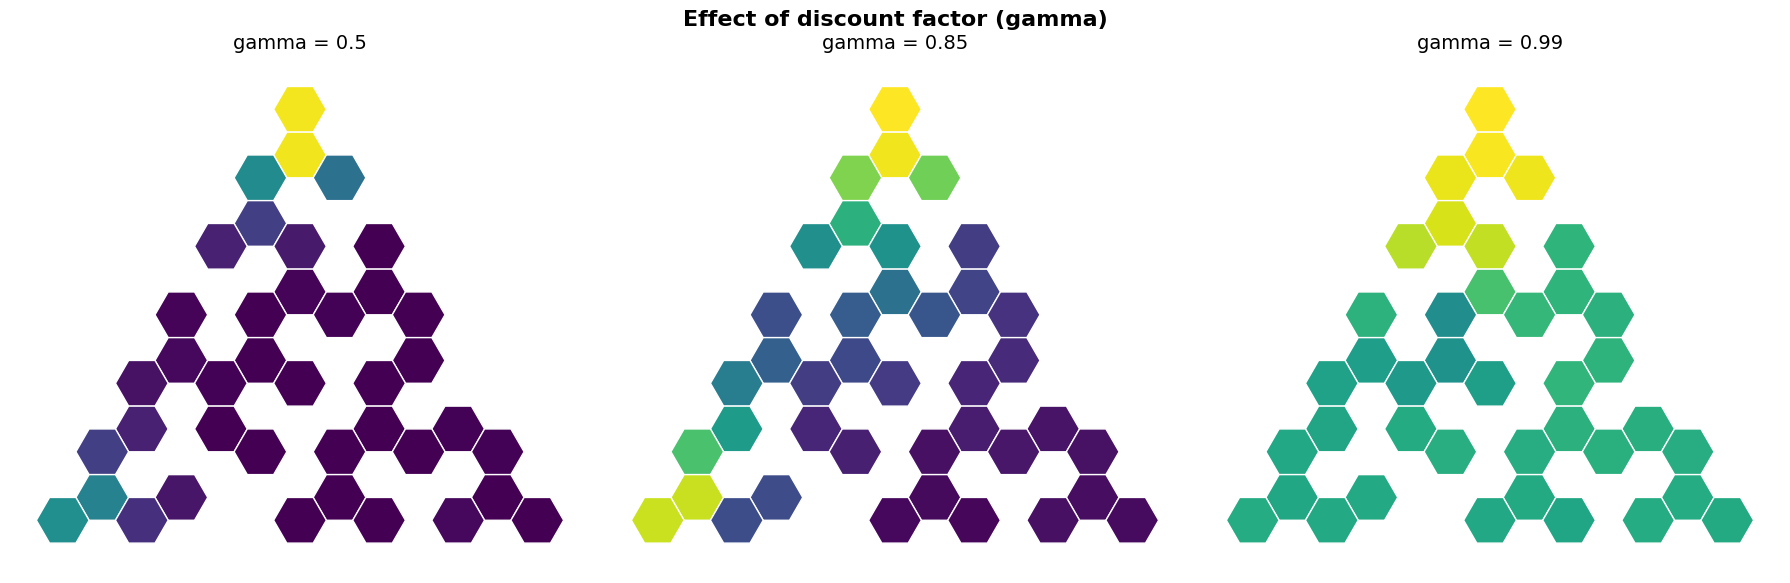

In [11]:
# Effect of gamma: higher gamma -> value propagates farther from reward ports
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, gamma in zip(axes, [0.5, 0.85, 0.99]):
    td_g = HexMazeTDLearner(maze, reward_probs, alpha=0.3, lam=0.6, gamma=gamma,
                            priors=reward_probs, temperature=0.5, no_backtrack=True)
    td_g.simulate(start_state=1, n_trials=200)
    plot_hex_maze(maze, color_by=td_g.get_max_state_values(),
                  colormap='viridis', vmin=0, vmax=1, ax=ax, show_hex_labels=False, show_barriers=False)
    ax.set_title(f'gamma = {gamma}', fontsize=14)
fig.suptitle('Effect of discount factor (gamma)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Learning curves

Reward rate and path length over trials (starting from scratch, no priors).

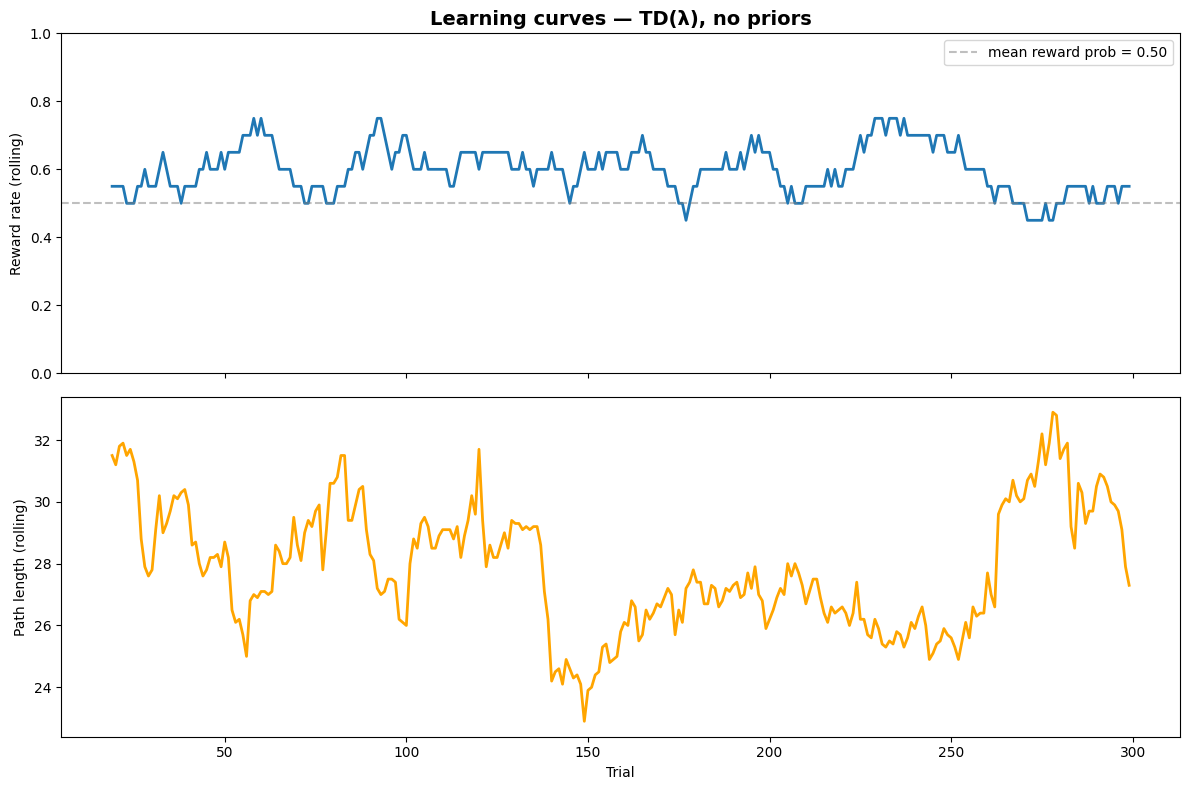

In [12]:
td_lc = HexMazeTDLearner(maze, reward_probs, alpha=0.3, lam=0.6, gamma=0.95,
                         temperature=0.5, no_backtrack=True)
results_lc = td_lc.simulate(start_state=1, n_trials=300)

rewards_lc = np.array([trial['reward'] for trial in results_lc])
lengths_lc = np.array([len(trial['path']) for trial in results_lc])
window = 20
reward_smooth = np.convolve(rewards_lc, np.ones(window)/window, mode='valid')
length_smooth = np.convolve(lengths_lc, np.ones(window)/window, mode='valid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(range(window-1, len(rewards_lc)), reward_smooth, linewidth=2)
ax1.axhline(np.mean(reward_probs), color='gray', linestyle='--', alpha=0.5,
            label=f'mean reward prob = {np.mean(reward_probs):.2f}')
ax1.set_ylabel('Reward rate (rolling)'); ax1.set_ylim(0, 1); ax1.legend()
ax1.set_title('Learning curves — TD(λ), no priors', fontsize=14, fontweight='bold')
ax2.plot(range(window-1, len(lengths_lc)), length_smooth, linewidth=2, color='orange')
ax2.set_ylabel('Path length (rolling)'); ax2.set_xlabel('Trial')
plt.tight_layout(); plt.show()

## Barrier changes with `set_graph()`

`set_graph()` swaps the maze graph while keeping learned values. States are re-created
lazily against the new graph (new hexes start at their prior, 0 by default); states on
hexes that no longer exist are dropped. This models a barrier change mid-session — the
agent keeps what it learned but adapts to the new layout.

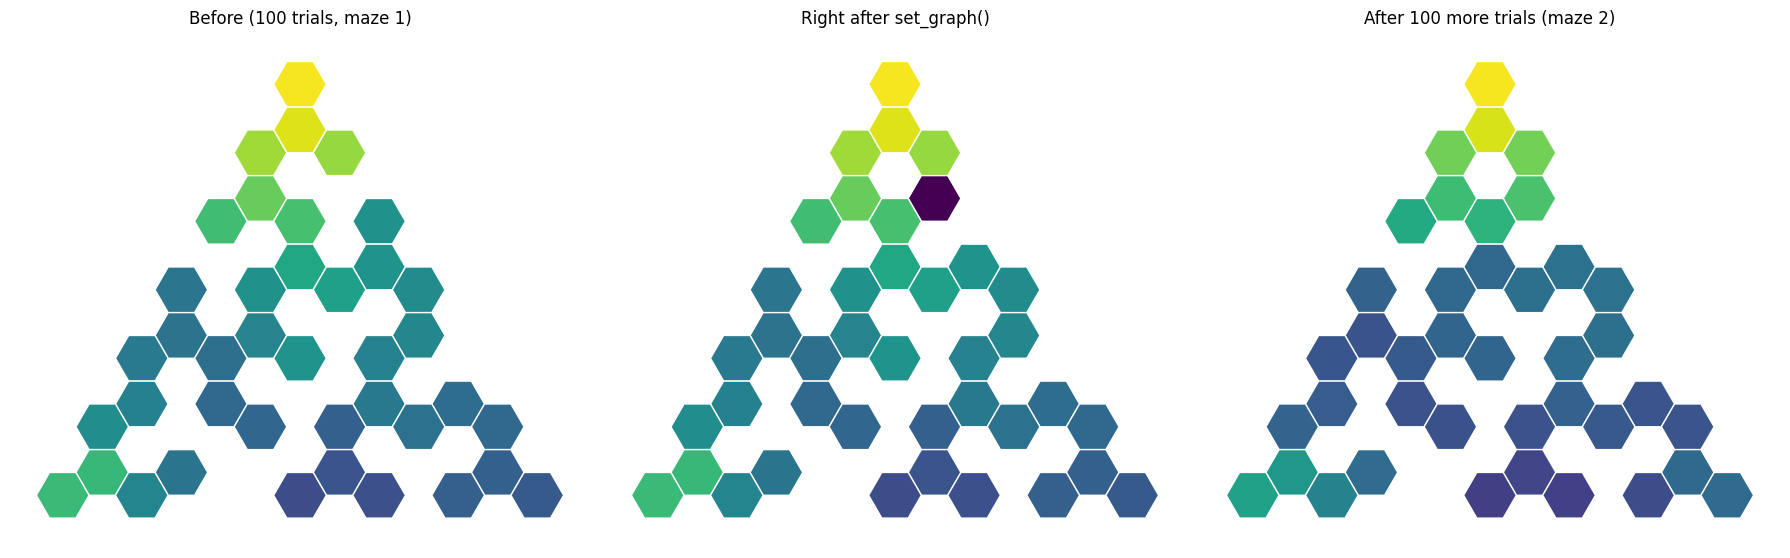

In [13]:
maze_1 = {37, 7, 39, 41, 14, 46, 20, 23, 30}

td_bc = HexMazeTDLearner(maze_1, reward_probs, alpha=0.3, lam=0.6, gamma=0.95,
                         priors=reward_probs, temperature=0.5, no_backtrack=True)
results_1 = td_bc.simulate(start_state=1, n_trials=100)
values_before = td_bc.get_max_state_values()

# Move a barrier from hex 7 to hex 9
maze_2 = {37, 9, 39, 41, 14, 46, 20, 23, 30}
td_bc.set_graph(maze_2)
values_after_swap = td_bc.get_max_state_values()

# Keep learning on the new maze
results_2 = td_bc.simulate(start_state=results_1[-1]['path'][-1], n_trials=100)
values_after_learning = td_bc.get_max_state_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_hex_maze(maze_1, color_by=values_before, colormap='viridis', vmin=0, vmax=1,
              ax=axes[0], show_hex_labels=False, show_barriers=False)
axes[0].set_title('Before (100 trials, maze 1)', fontsize=12)
plot_hex_maze(maze_2, color_by=values_after_swap, colormap='viridis', vmin=0, vmax=1,
              ax=axes[1], show_hex_labels=False, show_barriers=False)
axes[1].set_title('Right after set_graph()', fontsize=12)
plot_hex_maze(maze_2, color_by=values_after_learning, colormap='viridis', vmin=0, vmax=1,
              ax=axes[2], show_hex_labels=False, show_barriers=False)
axes[2].set_title('After 100 more trials (maze 2)', fontsize=12)
plt.tight_layout(); plt.show()

## Other useful methods

In [14]:
# reset() -- clear all tables and re-apply priors
print("Before reset: V(hex 1) =", round(td.get_state_values(1)[1], 4))
td.reset()
print("After reset:  V(hex 1) =", round(td.get_state_values(1)[1], 4))

# process_trajectory() -- the single-trajectory update that learn() calls
# start_port defaults to path[0] when it is a reward port
td.process_trajectory([1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 28, 33, 48, 3], reward=1.0)
print("\nAfter one A->C trajectory (reward=1):")
for hex in [1, 10, 16, 24, 48, 3]:
    print(f"  V(hex {hex:2d}) = {td.get_state_values(1)[hex]:.4f}")

Before reset: V(hex 1) = 0.1299
After reset:  V(hex 1) = 0.2702

After one A->C trajectory (reward=1):
  V(hex  1) = 0.2675
  V(hex 10) = 0.2898
  V(hex 16) = 0.2862
  V(hex 24) = 0.3026
  V(hex 48) = 0.4991
  V(hex  3) = 0.3700
